# Customer churn: who is worth a call this week

A retention team cannot call every customer. The useful question is not *will this customer leave* but *which customers should we call first, and what do we say to them*.

This notebook trains the model in `src/train.py`, measures it on data it has not seen, and checks whether SHAP explains it correctly.

**Read this first: the data is synthetic.** `generate_sample_dataset()` creates 5,000 customers and decides who churns with fixed rules (inactive over 30 days, tenure under 6 months, more than 2 support tickets, a single product) plus random noise. That has two consequences:

1. Accuracy will be unrealistically high, because the model is learning a formula, not human behaviour.
2. We know the true drivers. So we can test whether SHAP finds them. On real data you never get that check.

In [1]:
import sys; sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, shap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from features import generate_sample_dataset
from train import FEATURES, TARGET

df = generate_sample_dataset(n_customers=5000)
print(df.shape, f"churn rate {df[TARGET].mean():.1%}")
df.head()

/usr/local/lib/python3.13/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(5000, 10) churn rate 22.2%


,customer_id,tenure_months,monthly_charges,total_transactions,avg_transaction_value,days_since_last_txn,support_tickets,product_count,digital_engagement_score,churned
0,CUST_00000,39,5503.539070,66,14998.834462,24,1,4,33.252638,0
1,CUST_00001,52,22687.469889,40,17632.493861,4,2,2,54.866814,0
2,CUST_00002,29,18333.114931,38,37462.958641,1,1,2,38.127480,0
3,CUST_00003,15,23559.704078,48,42422.668678,27,1,4,28.764043,0
4,CUST_00004,43,15875.711531,55,19131.230574,60,1,4,91.717526,0


## 1. A quick look at the data
Churn rate by each planted rule. If the generator works as described, each flag should clearly raise the churn rate.

In [2]:
flags = pd.DataFrame({
    'inactive > 30 days': df.days_since_last_txn > 30,
    'tenure < 6 months':  df.tenure_months < 6,
    'support tickets > 2': df.support_tickets > 2,
    'single product':     df.product_count == 1,
})
summary = pd.DataFrame({
    'share of customers': flags.mean(),
    'churn rate if true': [df.loc[flags[c], TARGET].mean() for c in flags],
    'churn rate if false': [df.loc[~flags[c], TARGET].mean() for c in flags],
}).round(3)
summary

,share of customers,churn rate if true,churn rate if false
inactive > 30 days,0.280,0.705,0.033
tenure < 6 months,0.083,0.440,0.202
support tickets > 2,0.126,0.405,0.195
single product,0.245,0.351,0.180


## 2. Train on 80%, test on the 20% the model never sees
The original script only cross-validated and then trained on everything, which leaves no untouched data to report precision and recall on. Here a stratified holdout is set aside first.

In [3]:
X, y = df[FEATURES], df[TARGET]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.8,
                      colsample_bytree=0.8, scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
                      random_state=42, eval_metric='auc')
cv = cross_val_score(model, X_tr, y_tr, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring='roc_auc')
model.fit(X_tr, y_tr)
p = model.predict_proba(X_te)[:, 1]; pred = (p >= 0.5).astype(int)

metrics = pd.Series({
    'CV ROC-AUC (train, 5 folds)': cv.mean(),
    'Holdout ROC-AUC': roc_auc_score(y_te, p),
    'Holdout precision': precision_score(y_te, pred),
    'Holdout recall': recall_score(y_te, pred),
    'Holdout F1': f1_score(y_te, pred),
}).round(3)
metrics

CV ROC-AUC (train, 5 folds)    0.972
Holdout ROC-AUC                0.962
Holdout precision              0.677
Holdout recall                 0.896
Holdout F1                     0.771
dtype: float64

These numbers are high because the label is a formula of the inputs. On real customer data, expect much lower. Treat them as proof the pipeline runs end to end, not as a result.

## 3. The business view: how many churners does each call find?
Rank the test customers by predicted risk and ask: if the team calls the top 10%, 20% or 30%, what share of all churners do they reach?

In [4]:
ranked = pd.DataFrame({'p': p, 'y': y_te.values}).sort_values('p', ascending=False).reset_index(drop=True)
total = ranked.y.sum()
rows = []
for share in [0.1, 0.2, 0.3, 0.5]:
    top = ranked.head(int(len(ranked) * share))
    rows.append({'call top': f'{share:.0%}', 'customers called': len(top),
                 'churners reached': int(top.y.sum()), 'share of all churners': round(top.y.sum() / total, 3),
                 'hit rate': round(top.y.mean(), 3)})
lift = pd.DataFrame(rows); lift

,call top,customers called,churners reached,share of all churners,hit rate
0,10%,100,100,0.450,1.000
1,20%,200,152,0.685,0.760
2,30%,300,201,0.905,0.670
3,50%,500,222,1.000,0.444


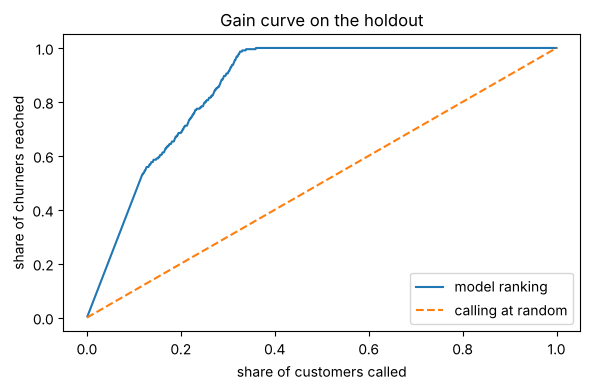

In [5]:
plt.figure(figsize=(6, 4))
x = np.arange(1, len(ranked) + 1) / len(ranked)
plt.plot(x, ranked.y.cumsum() / total, label='model ranking')
plt.plot([0, 1], [0, 1], '--', label='calling at random')
plt.xlabel('share of customers called'); plt.ylabel('share of churners reached')
plt.title('Gain curve on the holdout'); plt.legend(); plt.tight_layout(); plt.show()

## 4. Does SHAP find the drivers we planted?
Four features drive churn in the generator: `days_since_last_txn`, `tenure_months`, `support_tickets` and `product_count`. The other four are pure noise. If SHAP is working, those four should rank at the top.

In [6]:
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_te)
importance = pd.Series(np.abs(sv).mean(axis=0), index=FEATURES).sort_values(ascending=False)
planted = {'days_since_last_txn', 'tenure_months', 'support_tickets', 'product_count'}
check = importance.to_frame('mean |SHAP|').round(4)
check['planted driver?'] = ['yes' if f in planted else 'no' for f in check.index]
check

,mean |SHAP|,planted driver?
days_since_last_txn,4.2776,yes
product_count,1.2642,yes
support_tickets,1.0203,yes
tenure_months,0.8466,yes
monthly_charges,0.2303,no
digital_engagement_score,0.2168,no
avg_transaction_value,0.1874,no
total_transactions,0.1826,no


Top 4 by SHAP are exactly the planted drivers: True


/tmp/ipykernel_373/2320654417.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, X_te, show=True)


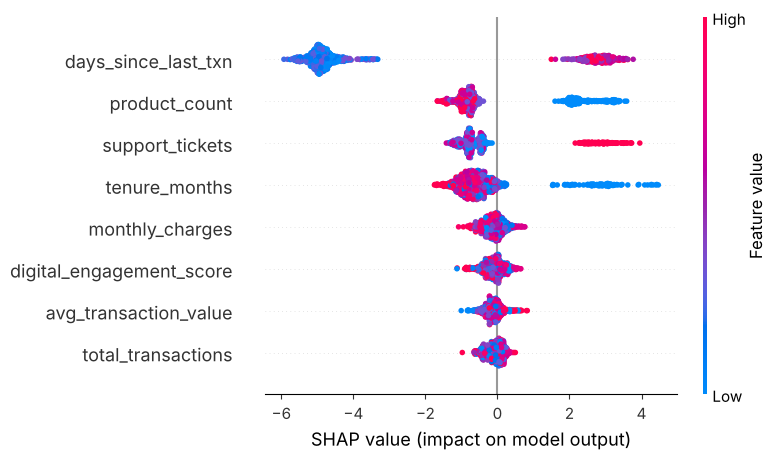

In [7]:
top4 = set(importance.index[:4])
print('Top 4 by SHAP are exactly the planted drivers:', top4 == planted)
shap.summary_plot(sv, X_te, show=True)

## 5. Explaining one customer to the agent making the call

In [8]:
i = int(np.argmax(p))
c = X_te.iloc[i]
contrib = pd.Series(sv[i], index=FEATURES).sort_values(key=abs, ascending=False)
print(f'Predicted churn risk: {p[i]:.1%}')
pd.DataFrame({'value': c[contrib.index], 'pushes risk by': contrib.round(3)})

Predicted churn risk: 100.0%


,value,pushes risk by
support_tickets,4.000000,2.871
product_count,1.000000,2.806
days_since_last_txn,49.000000,2.669
avg_transaction_value,49328.114034,0.492
tenure_months,42.000000,-0.401
monthly_charges,11381.606560,-0.371
total_transactions,80.000000,0.143
digital_engagement_score,40.176255,-0.111


## What this shows, and where it stops

- **The pipeline works end to end**: features in, risk ranking out, with a per-customer explanation an agent can act on.
- **SHAP recovered the planted drivers.** That is the most useful result here, because it is the one check you cannot run on real data.
- **The accuracy figures are not evidence of real-world performance.** The label is a formula with a little noise, so a tree model will score close to perfect.
- **Next step:** run the same notebook on a real or public dataset (for example the IBM Telco churn data) and report those numbers instead.